In [89]:
import numpy as np
import pandas as pd

In [90]:
df = pd.read_csv("placement.xls")
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [91]:
df = df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [92]:
import matplotlib.pyplot as plt

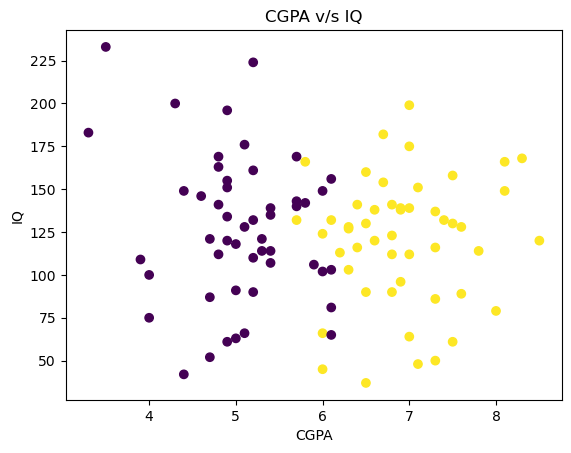

In [93]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("CGPA v/s IQ")
plt.show()

In [94]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]
x,y

(    cgpa     iq
 0    6.8  123.0
 1    5.9  106.0
 2    5.3  121.0
 3    7.4  132.0
 4    5.8  142.0
 ..   ...    ...
 95   4.3  200.0
 96   4.4   42.0
 97   6.7  182.0
 98   6.3  103.0
 99   6.2  113.0
 
 [100 rows x 2 columns],
 0     1
 1     0
 2     0
 3     1
 4     0
      ..
 95    0
 96    0
 97    1
 98    1
 99    1
 Name: placement, Length: 100, dtype: int64)

In [95]:
x.shape,y.shape

((100, 2), (100,))

# **Feature extraction**

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3)
X_train,X_test,y_train,y_test

(    cgpa     iq
 74   6.7  154.0
 32   7.0  139.0
 76   4.9  155.0
 95   4.3  200.0
 15   5.1  176.0
 ..   ...    ...
 48   6.6  138.0
 52   7.0  175.0
 39   4.6  146.0
 67   5.0  118.0
 2    5.3  121.0
 
 [70 rows x 2 columns],
     cgpa     iq
 64   7.0   64.0
 51   4.8  141.0
 7    5.0   63.0
 42   7.6   89.0
 31   3.9  109.0
 60   6.9  139.0
 8    6.1  156.0
 56   6.1   65.0
 89   4.9  151.0
 91   7.5  158.0
 71   6.1  132.0
 96   4.4   42.0
 16   5.2  224.0
 99   6.2  113.0
 3    7.4  132.0
 30   7.6  128.0
 81   5.4  107.0
 69   8.5  120.0
 85   5.8  166.0
 23   4.7   87.0
 72   7.3  116.0
 22   4.9  120.0
 70   6.3  127.0
 37   8.1  149.0
 29   7.0  112.0
 40   4.9  134.0
 57   6.5  130.0
 84   5.7  169.0
 79   6.5   90.0
 90   7.3   86.0,
 74    1
 32    1
 76    0
 95    0
 15    0
      ..
 48    1
 52    1
 39    0
 67    0
 2     0
 Name: placement, Length: 70, dtype: int64,
 64    1
 51    0
 7     0
 42    1
 31    0
 60    1
 8     0
 56    0
 89    0
 91    1
 71    1


In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler = StandardScaler()

In [99]:

X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.71453667,  0.71561769],
       [ 0.98490189,  0.34746552],
       [-0.90765469,  0.74016117],
       [-1.44838514,  1.84461768],
       [-0.7274112 ,  1.25557421],
       [ 1.4355106 , -1.56692576],
       [ 0.62441493, -0.11886056],
       [-0.00643727, -0.46246925],
       [ 0.53429318,  0.86287856],
       [ 0.44417144, -0.21703447],
       [-1.71875036, -1.22331707],
       [ 0.08368447, -1.95962141],
       [ 0.89478015, -0.70790403],
       [ 0.17380622, -0.53609968],
       [ 0.89478015,  0.32292205],
       [ 0.98490189,  1.8200742 ],
       [-0.99777643,  0.936509  ],
       [-0.99777643,  1.08376986],
       [-0.90765469, -1.56692576],
       [-0.63728946,  0.17566118],
       [-0.63728946,  0.88742204],
       [-1.08789817, -1.78781706],
       [-0.90765469,  1.74644377],
       [ 0.08368447, -0.02068665],
       [ 0.17380622, -1.0760562 ],
       [-2.34960256,  1.42737856],
       [ 0.80465841, -0.8551649 ],
       [-0.45704598, -0.26612143],
       [ 2.15648454,

In [100]:
X_test = scaler.transform(X_test)

In [101]:
from sklearn.linear_model import LogisticRegression

In [102]:
clf = LogisticRegression()

In [103]:
clf.fit(X_train,y_train)

LogisticRegression()

In [104]:
print(clf.coef_)
clf.intercept_

[[ 3.05259408 -0.17066463]]


array([-0.30552265])

In [105]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1])

In [106]:
y_test

64    1
51    0
7     0
42    1
31    0
60    1
8     0
56    0
89    0
91    1
71    1
96    0
16    0
99    1
3     1
30    1
81    0
69    1
85    1
23    0
72    1
22    0
70    1
37    1
29    1
40    0
57    1
84    0
79    1
90    1
Name: placement, dtype: int64

In [107]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
score

0.9

<Axes: >

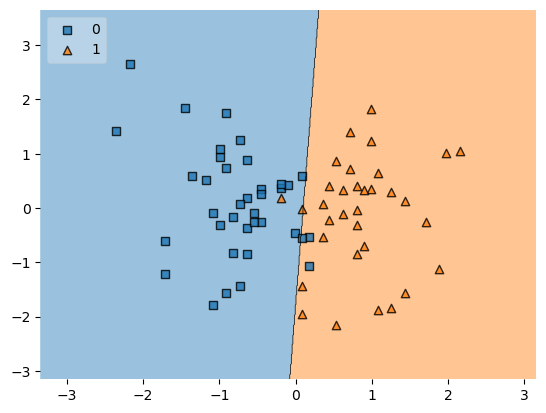

In [108]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [109]:
import pickle

In [ ]:
# pickle.dump(clf,open("model.pkl","wb"))